Step 1: Imports

In [24]:
#Standard imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Sklearn imports
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score

#Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

#Metrics & Utilities imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")


df_fe = pd.read_csv("../data/processed_data.csv")



Step 2: Preprocessing pipeline that encodes categorical features and scales numerical ones

In [7]:
# Define features and target
target = 'churn'
drop_cols = ['customer_id']
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = ['credit_score','age','tenure','balance','products_number','estimated_salary',
                    'balance_per_product','salary_balance_ratio']
categorical_features = ['country','gender','credit_card','active_member','age_group','tenure_bucket','high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


Step 3: Train Test Split

In [8]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


Step 4: Train Multiple models with a pipeline and compare using cross-validation

In [9]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.7878 Std=0.0244
RandomForest AUC: Mean=0.8494 Std=0.0111
GradientBoosting AUC: Mean=0.8611 Std=0.0094
AdaBoost AUC: Mean=0.8462 Std=0.0133
SVC AUC: Mean=0.8349 Std=0.0102
XGBoost AUC: Mean=0.8579 Std=0.0112


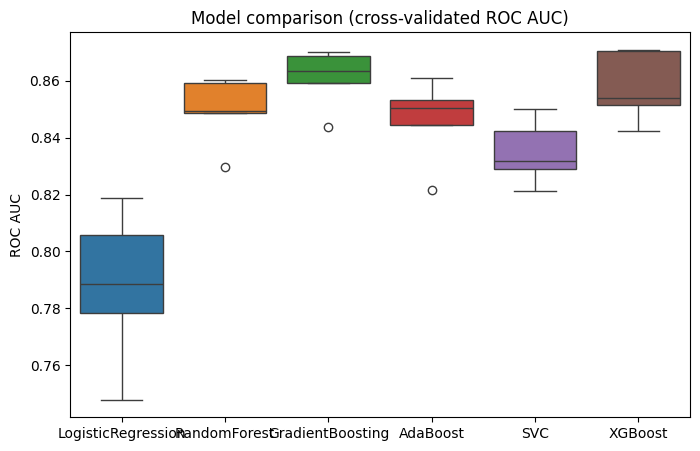

In [10]:
# Boxplot of CV AUC scores
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

Step 5: Fit best model on full train set and evaluate on test set

In [11]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', np.float64(0.8611296241007022))

Test Accuracy: 0.8670
Test Precision: 0.7787
Test Recall: 0.4840
Test F1-score: 0.5970
Test ROC AUC: 0.8714

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



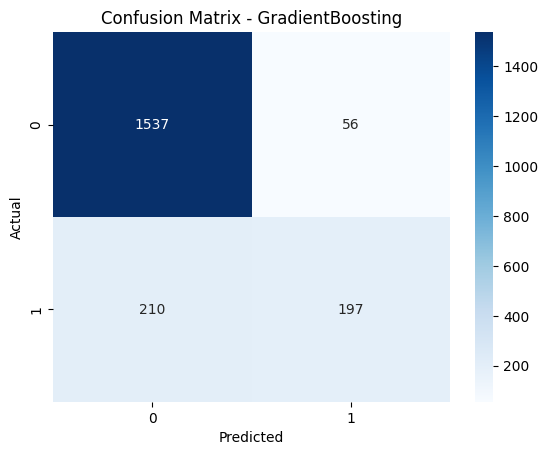

In [14]:
best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', best_model)])
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

Step 10. Feature importance 


age                     0.325433
products_number         0.266616
active_member_0         0.065240
balance_per_product     0.063272
balance                 0.052189
country_Germany         0.050137
active_member_1         0.034685
salary_balance_ratio    0.030802
estimated_salary        0.029817
credit_score            0.023250
age_group_45-54         0.021618
age_group_55-64         0.008112
gender_Male             0.006666
gender_Female           0.006554
tenure                  0.004615
country_France          0.003544
age_group_35-44         0.002614
tenure_bucket_3-5       0.002156
credit_card_0           0.001049
tenure_bucket_0         0.000586
dtype: float64

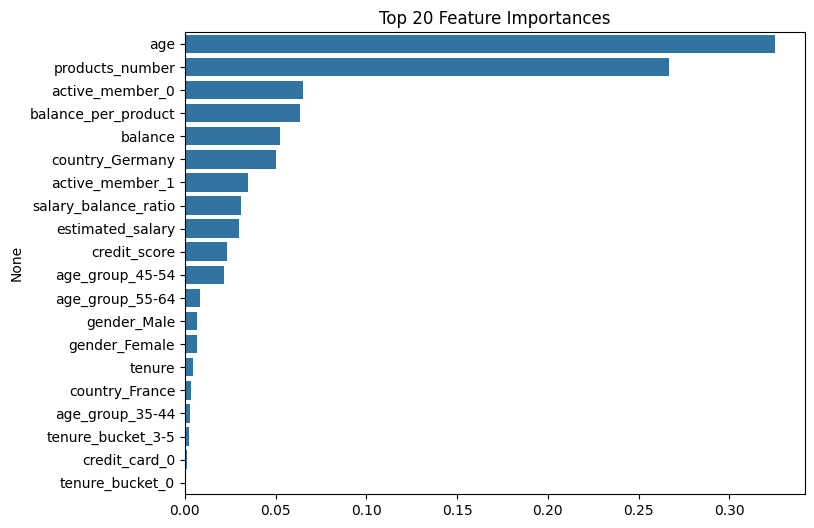

In [15]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_feats = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
    feature_names = num_feats + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    display(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.show()
else:
    print('Selected model does not provide feature_importances_ attribute.')

Step 11. Save the best pipeline and preprocessing artifacts


In [26]:
joblib.dump(best_pipeline, '../models/best_churn_pipeline.pkl')

print("Saved pipeline in models/best_churn_pipeline.pkl")

Saved pipeline in models/best_churn_pipeline.pkl


Step 12:  Predict churn for a new customer

In [23]:
# --- New customer sample ---
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# Feature Engineering


# Balance per product
sample_df['balance_per_product'] = sample_df['balance'] / sample_df['products_number']
sample_df['balance_per_product'] = (
    sample_df['balance_per_product']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# Salary to balance ratio
sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / sample_df['balance']
sample_df['salary_balance_ratio'] = (
    sample_df['salary_balance_ratio']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(sample_df['salary_balance_ratio'].median())
)

# Age group
bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']

sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

# Tenure bucket
sample_df['tenure_bucket'] = pd.cut(
    sample_df['tenure'],
    bins=[-1,0,2,5,10,100],
    labels=['0','1-2','3-5','6-10','10+']
)

# High balance flag (use training distribution)
threshold = df_fe['balance'].quantile(0.75)
sample_df['high_balance'] = (sample_df['balance'] > threshold).astype(int)

# Drop unnecessary columns

sample_df = sample_df.drop(columns=['customer_id'])

# Prediction

pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0, 1]

print(f"Predicted churn: {pred}")
print(f"Probability of churn: {prob:.3f}")

Predicted churn: 0
Probability of churn: 0.029
